# Clasificación: práctica y ejercicios

**NOTAS**
 - Hay muchas formas de resolver cada problema, encuentra la tuya.
 - Crea las celdas extra que necesites.
 - Recuerda que una celda puede ser de tipo Código, o de tipo Markdown. Utiliza las segundas para escribir texto y explicaciones si lo precisas.
 - Intenta crear variables a la hora de resolver los ejercicios.
 - Puedes apoyarte en internet: todos los programadores lo hacemos a diario.

**El objetivo de hoy es entrenar un modelo de machine learning y hacer una submission a Kaggle**

## Preliminares

Regístrate en [Kaggle](https://www.kaggle.com/)

Navega hasta la competición del [Titanic](https://www.kaggle.com/competitions/titanic)

Navega por las pestañas 
 - Overview - Description
 - Overview - Evaluation
 - Data
 - (en la pestaña Code se aprende muchísimo, pero hoy mejor no)

## Carga de datos

Descarga los datos

Recuerda:
 - el train viene etiquetado. Lo usarás para entrenar el/los modelos
 - el test **no** viene etiquetado. Te piden predecir sobre ese subconjunto

In [1]:
import pandas as pd

In [2]:
import seaborn as sns

In [3]:
from datetime import datetime

In [4]:
df = pd.read_csv("./datasets/titanic_kaggle/train.csv")

## Exploración de datos

Haz análisis univariantes, bivariantes y multivariantes  
Acompaña tus análisis con gráficas

In [5]:
df.shape

(891, 12)

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Survived', ylabel='count'>

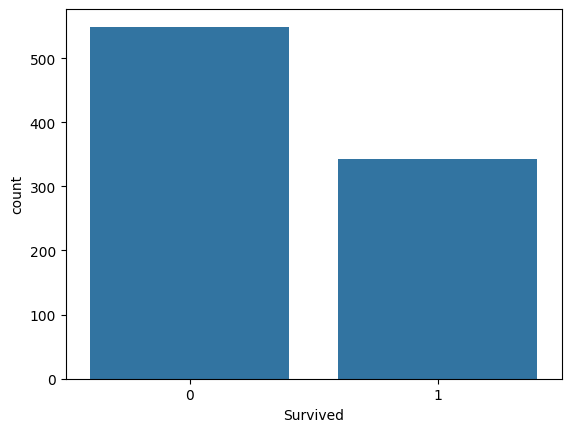

In [7]:
sns.countplot(x=df.Survived)

<Axes: xlabel='Pclass', ylabel='count'>

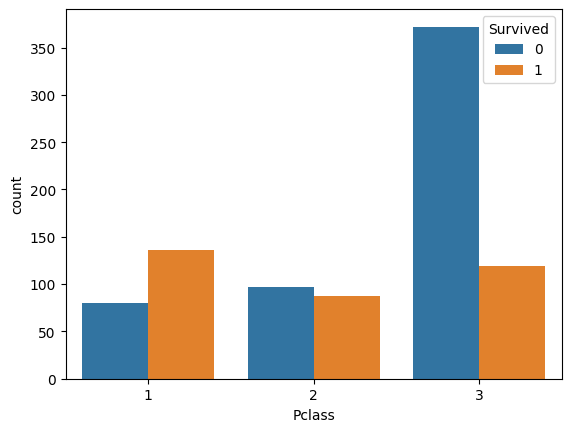

In [8]:
sns.countplot(hue=df.Survived, x=df.Pclass)

<Axes: xlabel='Age', ylabel='Density'>

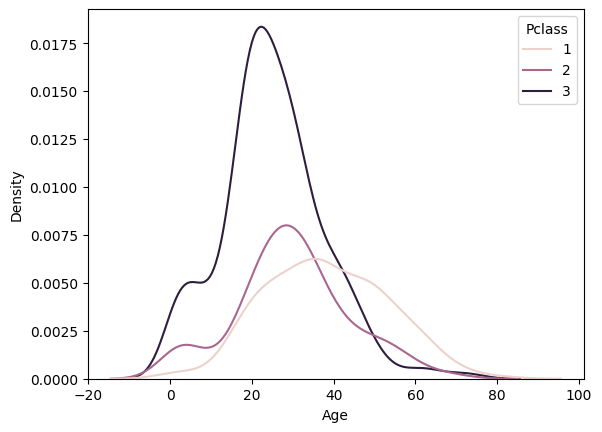

In [9]:
sns.kdeplot(x=df.Age, hue=df.Pclass)

<Axes: xlabel='Age', ylabel='Density'>

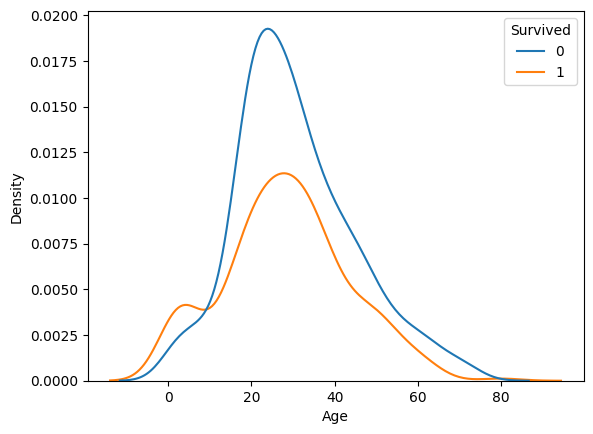

In [10]:
sns.kdeplot(x=df.Age, hue=df.Survived)

In [11]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
df.SibSp.value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [13]:
pd.crosstab(df.SibSp, df.Survived)

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


## Crea modelos que predigan la supervivencia

### Modelo sencillo

- Entrena un modelo sencillo: utiliza solo el sexo de los pasajeros
- Haz predicciones sobre el test
- Submite a Kaggle tus resultados. Qué score obtienes?

In [14]:
from sklearn.linear_model import LogisticRegression

In [15]:
log = LogisticRegression()

In [16]:
df.Sex.isna().sum()

np.int64(0)

In [17]:
df.Sex = df.Sex.map({"male": 0, "female": 1})

In [18]:
log.fit(
    X=df[["Sex"]],
    y=df.Survived
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Predict

In [19]:
df_test = pd.read_csv("./datasets/titanic_kaggle/test.csv")

preprocess

In [20]:
df_test.Sex = df_test.Sex.map({"male": 0, "female": 1})

In [21]:
preds_test = log.predict(df_test[["Sex"]])

In [22]:
preds_test[:10]

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0])

In [23]:
submission = df_test[["PassengerId"]].copy()

In [24]:
submission["Survived"] = preds_test

In [25]:
submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [26]:
now = datetime.now().strftime("%Y-%M-%d---%H%m%s")

In [27]:
submission.to_csv(f"./datasets/titanic_kaggle/submission_{now}.csv", index=False)

### Modelos más complejos

Mejora tu modelo base añadiendo más variables

Ideas:
 - utiliza el sexo del pasajero, que puedes pasar a 0/1
 - utiliza la edad, imputando los nulos con alguna estrategia
 - utiliza la puerta de embarque
 - utiliza la letra de la cabina
 - imputa los nulos

In [218]:
df = pd.read_csv("./datasets/titanic_kaggle/train.csv")

In [219]:
df.Sex = df.Sex.map({"male": 0, "female": 1})

In [220]:
df.Age = df.Age.fillna(df.Age.mean())

In [221]:
df.Fare = df.Fare < 8

In [222]:
pd.crosstab(df.Embarked, df.Survived)

Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,217


In [223]:
prob_surv = df.groupby("Embarked").Survived.mean().round(2)

In [224]:
prob_surv

Embarked
C    0.55
Q    0.39
S    0.34
Name: Survived, dtype: float64

In [225]:
df.Embarked = df.Embarked.fillna("Q")

In [226]:
df.Embarked = df.Embarked.map(prob_surv)

In [257]:
df.Ticket = df.Ticket.apply(lambda t: t.isdigit())

In [260]:
log = LogisticRegression(max_iter=1000)

In [261]:
log.fit(
    X=df[["Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "Ticket"]],
    y=df.Survived
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Predict

In [262]:
df_test = pd.read_csv("./datasets/titanic_kaggle/test.csv")

preprocess

In [263]:
df_test.Sex = df_test.Sex.map({"male": 0, "female": 1})

In [264]:
df_test.Age = df_test.Age.fillna(df_test.Age.mean())

In [265]:
df_test.Fare = df_test.Fare.fillna(30.0)

In [266]:
df_test.Fare = df_test.Fare < 8

In [267]:
df_test.Embarked = df_test.Embarked.fillna("Q")

In [268]:
df_test.Embarked = df_test.Embarked.map(prob_surv)

In [269]:
df_test.Ticket = df_test.Ticket.apply(lambda t: t.isdigit())

In [270]:
preds_test = log.predict(df_test[["Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "Ticket"]])

In [271]:
preds_test.sum()

np.int64(146)

In [272]:
preds_test[:10]

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0])

In [273]:
submission = df_test[["PassengerId"]].copy()

In [274]:
submission["Survived"] = preds_test

In [275]:
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [276]:
now = datetime.now().strftime("%Y-%m-%d---%H%M%s")

In [277]:
submission.to_csv(f"./datasets/titanic_kaggle/submission_{now}.csv", index=False)